    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [35]:
# =============================================================================
# 1. Random Data  (same as before)
# =============================================================================
stock_names = [f"S{i+1}" for i in range(N_STOCKS)]
mu    = np.random.uniform(0.001, 0.01, N_STOCKS)
sigma = np.random.uniform(0.01,   0.05,  N_STOCKS)
returns_np  = np.random.normal(mu, sigma, size=(N_DAYS, N_STOCKS))  # (252, 10)

dates       = pd.bdate_range(end="2025-12-31", periods=N_DAYS)
returns_df  = pd.DataFrame(returns_np, index=dates, columns=stock_names)

IS_END_IDX  = N_DAYS // 2   # 126  ── IS/OOS boundary
BT_START    = IS_END_IDX    # backtest starts here

print(f"IS  : {dates[0].date()} → {dates[IS_END_IDX-1].date()}  ({IS_END_IDX} days)")
print(f"BT  : {dates[BT_START].date()} → {dates[-1].date()}  ({N_DAYS - BT_START} days)")


IS  : 2025-01-14 → 2025-07-08  (126 days)
BT  : 2025-07-09 → 2025-12-31  (126 days)


In [36]:
def make_windows(arr, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z      = arr[t - lookback : t].flatten()   # (lookback * m,)
        r_real = arr[t : t + horizon]              # (N, m)
        samples.append((z, r_real))
    return samples

# IS samples  (need lookback history → start from index LOOKBACK)
is_samples    = make_windows(returns_np, LOOKBACK, HORIZON,
                              start=LOOKBACK, end=IS_END_IDX)

# BT samples  (all windows in OOS, step by step)
bt_samples_all = make_windows(returns_np, LOOKBACK, HORIZON,
                               start=BT_START, end=N_DAYS)

# Monthly rebalancing: one window per HORIZON days
rebal_samples = bt_samples_all[::HORIZON]

print(f"\nIS training windows : {len(is_samples)}")
print(f"BT rebal windows    : {len(rebal_samples)}")



IS training windows : 85
BT rebal windows    : 6


In [37]:


# =============================================================================
# Step 1. Prediction Model: z -> r_hat
# =============================================================================

class PredictionModel(nn.Module):
   
    def __init__(self, input_dim: int, hidden_dim: int, N: int, m: int):
        super().__init__()
        self.N = N
        self.m = m
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, N * m),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
  
        batch = z.shape[0]
        out = self.net(z)               # (batch, N*m)
        r_hat = out.view(batch, self.N, self.m)
        return r_hat


# =============================================================================
# Step 2. Cumulative Return Path: r_hat -> y_hat
# =============================================================================

def compute_cumulative_path(r: torch.Tensor) -> torch.Tensor:
  
    y = torch.cumsum(r, dim=1)  # t축으로 누적합
    return y


# =============================================================================
# Step 3. Optimization Layer: y_hat -> x_star  (Formulation 16)
# =============================================================================

def build_optimization_layer(N: int, m: int) -> CvxpyLayer:
   
    # --- cvxpy 변수 ---
    x = cp.Variable(m, name="x")           # 포트폴리오 가중치 (m,)
    u = cp.Variable(N + 1, name="u")       # running max 보조변수 (N+1,) : u[0],...,u[N]

    # --- cvxpy 파라미터 ---
    Y_hat = cp.Parameter((N, m), name="Y_hat")   # 예측 누적 수익률 경로
    n1C   = cp.Parameter(nonneg=True, name="n1C") # drawdown 한도
    x_min = cp.Parameter(name="x_min")
    x_max = cp.Parameter(name="x_max")

    # --- 목적함수: y_hat(N)^T x 최대화 ---
    # Y_hat[N-1] == y_hat(t=N) (0-indexed)
    objective = cp.Maximize(Y_hat[N - 1] @ x)

    # --- 제약식 ---
    constraints = []

    # u_0 = 0
    constraints.append(u[0] == 0)

    for k in range(1, N + 1):
        y_k = Y_hat[k - 1]          # y_hat(t=k), shape (m,)

        # drawdown 제약: u_k - y_k^T x <= n1C
        constraints.append(u[k] - y_k @ x <= n1C)

        # running max >= 현재 포트폴리오 cumulative return
        constraints.append(u[k] >= y_k @ x)

        # running max 단조증가
        constraints.append(u[k] >= u[k - 1])

    # box constraint
    constraints.append(x >= x_min)
    constraints.append(x <= x_max)
    constraints.append(cp.sum(x) == 1)

    # --- 문제 정의 ---
    problem = cp.Problem(objective, constraints)
    assert problem.is_dcp(), "Problem is not DCP!"

    # --- CvxpyLayer 생성 ---
    layer = CvxpyLayer(
        problem,
        parameters=[Y_hat, n1C, x_min, x_max],
        variables=[x, u],
    )
    return layer


def solve_portfolio(
    y_hat: torch.Tensor,
    opt_layer: CvxpyLayer,
    n1: float,
    C: float,
    x_min: float,
    x_max: float,
) -> torch.Tensor:
    
    batch, N, m = y_hat.shape

    n1C_val   = torch.tensor(n1 * C, dtype=torch.float64)
    x_min_val = torch.tensor(x_min, dtype=torch.float64)
    x_max_val = torch.tensor(x_max, dtype=torch.float64)

    x_stars = []
    for b in range(batch):
        Y_hat_b = y_hat[b].double()  # (N, m)
        x_star_b, _ = opt_layer(
            Y_hat_b,
            n1C_val,
            x_min_val,
            x_max_val,
            solver_args={"solve_method": "ECOS"},
        )
        x_stars.append(x_star_b.float())

    x_star = torch.stack(x_stars, dim=0)  # (batch, m)
    return x_star


# =============================================================================
# Step 4. Realized Portfolio Path: (x_star, y_real) -> w_real(t)
# =============================================================================

def compute_realized_path(
    x_star: torch.Tensor,
    y_real: torch.Tensor,
) -> torch.Tensor:

    # einsum: w_real[b,t] = sum_j x_star[b,j] * y_real[b,t,j]
    w_real = torch.einsum("bj, btj -> bt", x_star, y_real)  # (batch, N)
    return w_real


# =============================================================================
# Step 5. Performance Metrics: w_real -> R_real, M_real
# =============================================================================

def compute_return(
    w_real: torch.Tensor,
    d: float,
    C: float,
) -> torch.Tensor:
    
    R_real = w_real[:, -1] / (d * C)
    return R_real


def compute_max_drawdown(w_real: torch.Tensor) -> torch.Tensor:
    
    # running maximum up to each time step
    running_max, _ = torch.cummax(w_real, dim=1)  # (batch, N)

    # drawdown at each time step
    drawdown = running_max - w_real                # (batch, N)

    # maximum drawdown
    M_real = torch.max(drawdown, dim=1).values 
    # M_real = torch.logsumexp(beta * drawdown, dim=1) / beta   # (Gradient가 smooth 하지 않을 때 사용)
    return M_real



# def compute_max_drawdown_smoothing(w_real: torch.Tensor, beta: float = 100.0) -> torch.Tensor:
#     """
#     실현 MaxDD 계산 (differentiable 근사)

#     D_real(t) = max_{tau <= t} w_real(tau) - w_real(t)
#     M_real    = max_{1 <= t <= N} D_real(t)

#     Note:
#         torch.cummax는 미분 가능하지만 max는 argmax가 겹치면
#         gradient가 불안정할 수 있음.
#         DFL loss의 M_real 항은 gradient를 통해 theta를 업데이트하는 데 사용.

#     Args:
#         w_real : (batch, N)
#     Returns:
#         M_real : (batch,)
#     """
#     # running maximum up to each time step
#     running_max, _ = torch.cummax(w_real, dim=1)  # (batch, N)

#     # drawdown at each time step
#     drawdown = running_max - w_real                # (batch, N)

#     # maximum drawdown
#     # M_real = torch.max(drawdown, dim=1).values 
#     M_real = torch.logsumexp(beta * drawdown, dim=1) / beta   (Gradient가 smooth 하지 않을 때 사용)
#     return M_real



# =============================================================================
# Step 6. DFL Loss Function
# =============================================================================

def dfl_loss(
    R_real: torch.Tensor,
    M_real: torch.Tensor,
    lam: float,
) -> torch.Tensor:
   
    loss = (-R_real + lam * M_real).mean()
    return loss


# =============================================================================
# Full Pipeline (End-to-End)
# =============================================================================

def forward_pass(
    z: torch.Tensor,
    r_real: torch.Tensor,
    pred_model: PredictionModel,
    opt_layer: CvxpyLayer,
    n1: float,
    C: float,
    d: float,
    x_min: float,
    x_max: float,
    lam: float,
) -> dict:

    # Step 1: z -> r_hat
    r_hat = pred_model(z)                           # (batch, N, m)

    # Step 2: r_hat -> y_hat
    y_hat = compute_cumulative_path(r_hat)          # (batch, N, m)

    # Step 3: y_hat -> x_star  (LP)
    x_star = solve_portfolio(
        y_hat, opt_layer, n1, C, x_min, x_max
    )                                               # (batch, m)

    # Step 4: x_star + y_real -> w_real
    y_real = compute_cumulative_path(r_real)        # (batch, N, m)
    w_real = compute_realized_path(x_star, y_real)  # (batch, N)

    # Step 5: w_real -> R_real, M_real
    R_real = compute_return(w_real, d, C)           # (batch,)
    M_real = compute_max_drawdown(w_real)           # (batch,)

    # Step 6: Loss
    loss = dfl_loss(R_real, M_real, lam)            # scalar

    return {
        "r_hat" : r_hat,
        "y_hat" : y_hat,
        "x_star": x_star,
        "y_real": y_real,
        "w_real": w_real,
        "R_real": R_real,
        "M_real": M_real,
        "loss"  : loss,
    }


def plot_pnl(bt_results: list, horizon: int, figsize=(12, 6)):
 
    pv = [1.0]   # portfolio value, starts at 1
    rebal_indices = [0]

    for res in bt_results:
        w = res["w_real"]         
        base = pv[-1]
        pv.extend((base * (1 + w)).tolist())
        rebal_indices.append(len(pv) - 1)

    pv = np.array(pv)
    x  = np.arange(len(pv))

 
    running_max = np.maximum.accumulate(pv)
    drawdown    = (running_max - pv) / (running_max + 1e-10)

    total_ret = pv[-1] - 1.0
    max_dd    = drawdown.max()
    calmar    = total_ret / (max_dd + 1e-10)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsize,
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True
    )

    # -- PnL --
    ax1.plot(x, pv, color="steelblue", linewidth=1.8, label="DFL Portfolio")
    ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    for idx in rebal_indices[1:-1]:   # skip start & end
        ax1.axvline(idx, color="orange", linestyle=":", linewidth=1.0,
                    alpha=0.7, label="Rebalance" if idx == rebal_indices[1] else "")
    ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f"))
    ax1.set_ylabel("Portfolio Value")
    ax1.set_title(
        f"Cumulative PnL  |  Return: {total_ret:.2%}  "
        f"Max DD: {max_dd:.2%}  Calmar: {calmar:.2f}"
    )
    ax1.legend(loc="upper left", fontsize=9)
    ax1.grid(True, alpha=0.25)

    # -- Drawdown --
    ax2.fill_between(x, -drawdown * 100, 0, color="crimson", alpha=0.45, label="Drawdown")
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Trading Days (BT Period)")
    ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax2.legend(loc="lower left", fontsize=9)
    ax2.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    print(f"\n── PnL Summary ──")
    print(f"  Final Value  : {pv[-1]:.4f}")
    print(f"  Total Return : {total_ret:.4%}")
    print(f"  Max Drawdown : {max_dd:.4%}")
    print(f"  Calmar Ratio : {calmar:.4f}")


In [38]:
np.random.seed(42)
torch.manual_seed(42)

N_STOCKS   = 10
N_DAYS     = 252
LOOKBACK   = 21   # feature window  (past 1M of returns, flattened)
HORIZON    = 21   # prediction & rebalancing horizon (1M)

INPUT_DIM  = LOOKBACK * N_STOCKS   # 210
HIDDEN_DIM = 64
N          = HORIZON               # used inside framework
M          = N_STOCKS

n1    = 0.10   # drawdown limit factor
C     = 1.0    # initial capital
d     = float(N)   # return normalizer
x_min = 0.0    # long-only
x_max = 0.30   # max 30% per stock
lam   = 1.0    # loss weight on MDD

EPOCHS     = 50
BATCH_SIZE = 16
LR         = 1e-3


── IS Training ──
  Epoch   1/50  loss = 0.028322
  Epoch   5/50  loss = 0.026803
  Epoch  10/50  loss = 0.029448
  Epoch  15/50  loss = 0.027903
  Epoch  20/50  loss = 0.027903
  Epoch  25/50  loss = 0.028630
  Epoch  30/50  loss = 0.026369
  Epoch  35/50  loss = 0.028310
  Epoch  40/50  loss = 0.026842
  Epoch  45/50  loss = 0.028804
  Epoch  50/50  loss = 0.027969

── Backtest (walk-forward, monthly rebalancing) ──
 Win    R_real       MDD  Top-3 weights
-------------------------------------------------------
   1    0.0155    0.0164  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   2    0.0097    0.0163  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   3    0.0101    0.0212  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   4    0.0053    0.0626  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   5    0.0054    0.0413  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   6    0.0025    0.0724  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}


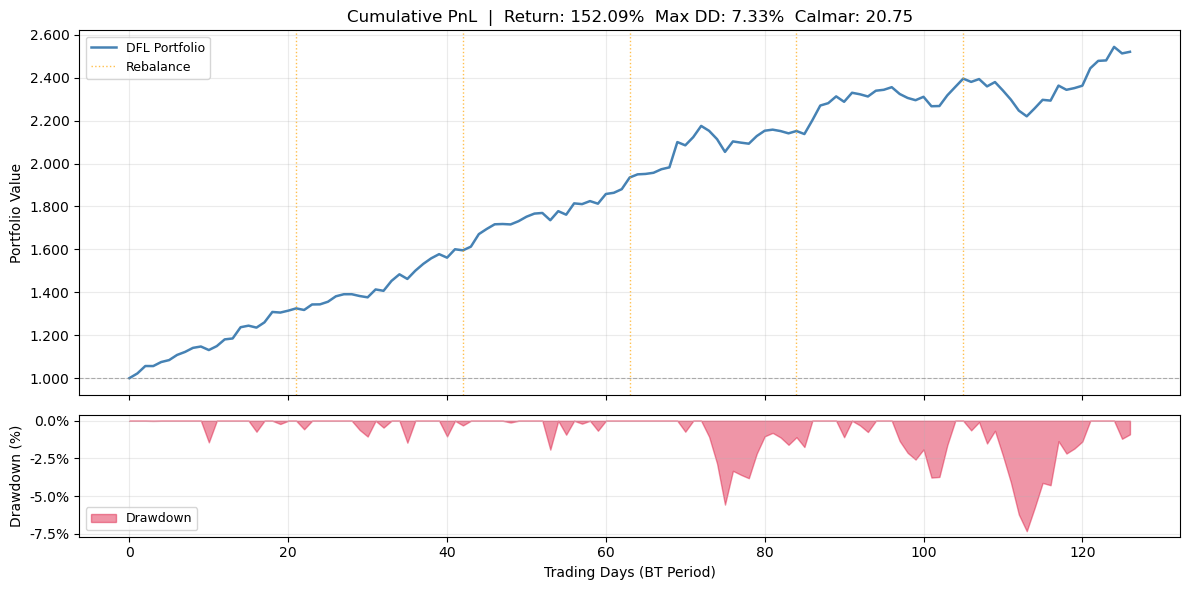


── PnL Summary ──
  Final Value  : 2.5209
  Total Return : 152.0902%
  Max Drawdown : 7.3290%
  Calmar Ratio : 20.7519


In [39]:


pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
opt_layer  = build_optimization_layer(N, M)
optimizer  = optim.Adam(pred_model.parameters(), lr=LR)

def to_tensors(samples):
    zs      = torch.tensor(np.array([s[0] for s in samples]), dtype=torch.float32)
    r_reals = torch.tensor(np.array([s[1] for s in samples]), dtype=torch.float32)
    return zs, r_reals   # (B, input_dim),  (B, N, m)

zs_is, rs_is = to_tensors(is_samples)


print("\n── IS Training ──")
pred_model.train()

for epoch in range(EPOCHS):
    perm   = torch.randperm(len(is_samples))
    ep_loss = []

    for i in range(0, len(is_samples), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        z_b = zs_is[idx]
        r_b = rs_is[idx]

        optimizer.zero_grad()
        result = forward_pass(z_b, r_b, pred_model, opt_layer,
                              n1, C, d, x_min, x_max, lam)
        result["loss"].backward()
        optimizer.step()
        ep_loss.append(result["loss"].item())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss = {np.mean(ep_loss):.6f}")


pred_model.eval()
bt_results = []

print("\n── Backtest (walk-forward, monthly rebalancing) ──")
print(f"{'Win':>4}  {'R_real':>8}  {'MDD':>8}  {'Top-3 weights'}")
print("-" * 55)

for i, (z_np, r_np) in enumerate(rebal_samples):
    z      = torch.tensor(z_np[None],  dtype=torch.float32)   # (1, input_dim)
    r_real = torch.tensor(r_np[None],  dtype=torch.float32)   # (1, N, m)

    with torch.no_grad():
        r_hat = pred_model(z)                        # (1, N, m)

    y_hat  = compute_cumulative_path(r_hat)          # (1, N, m)  — needs grad for layer
    x_star = solve_portfolio(y_hat.detach(), opt_layer, n1, C, x_min, x_max)  # (1, m)

    y_real = compute_cumulative_path(r_real)
    w_real = compute_realized_path(x_star, y_real)   # (1, N)
    R_real = compute_return(w_real, d, C)
    M_real = compute_max_drawdown(w_real)

    w = x_star[0].numpy()
    top3 = {stock_names[j]: round(w[j], 3)
            for j in np.argsort(w)[-3:][::-1]}

    bt_results.append({
        "window": i + 1,
        "weights": w,
        "w_real":  w_real[0].detach().numpy(),   # ← add this line
        "R_real":  R_real[0].item(),
        "M_real":  M_real[0].item(),
    })
    print(f"  {i+1:2d}  {R_real[0].item():8.4f}  {M_real[0].item():8.4f}  {top3}")


plot_pnl(bt_results, horizon=HORIZON)
